# scRNA-seq data analysis

Welcome to QIBS lab 1! In this lab, we will implement a standard scRNA-seq analysis pipeline, including

1. Data loading
2. Basic quality control
3. Data normalization and transformation
4. Feature selection
5. Dimensionality reduction
6. Cell typing

Our dataset for today is a PBMC scRNA-seq dataset from the 10X genomics platform: the data has already been processed from raw sequencing reads to filtered count matrices with the [10X CellRanger pipeline](https://www.10xgenomics.com/support/software/cell-ranger/latest) - additional data cleaning will be required before delving into analysis, though.

In a real-life analysis, you will likely use [_anndata_](https://anndata.readthedocs.io/en/stable/) and [_scanpy_](https://scanpy.readthedocs.io/en/stable/) to perform the outlined steps in Python. However, here, we will also implement each step using common Python packages for scientific computing like _numpy_, _pandas_, or _scipy_. To specify which kind of package and corresponding data to work with, we use the following color-codings for the exercises:

<div style="padding: 10px; border-radius: 1px; width: 60%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Not Scanpy-based</b>
  </div>
  <div style="width: 5%; display: inline-block"></div>
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Scanpy-based</b>
  </div>
  <div style="width: 5%; display: inline-block"></div>
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Both</b>
  </div>
</div>

Additionally, questions are color-coded green. Use the file _worksheet_1.xlsx_ to provide your answers and upload both the answer sheet and notebook to the Google Drive folder shared with you; name the files *worksheet_1_LASTNAME.xlsx* and *sc_basics_LASTNAME.ipynb*. **The deadline for submitting your answers is April 2 at 12pm ET**.

<div style="padding: 10px; border-radius: 1px; width: 60%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px; width: 20%; display: inline-block; text-align: center; vertical-align: middle">
    <b>Question</b>
  </div>
</div>

## Setup instructions

Copy the data relevant for this lab into the repositories data directory.

```bash
cp -r /athena/qibs_class/scratch/pfw4001/data/lab_1 /athena/qibs_class/scratch/CWID/qibs2026/data/
```

Let's begin!

## Library imports

In [1]:
from natsort import natsorted

import numpy as np
import pandas as pd
import scipy
from igraph import Graph
from scipy.sparse import csr_matrix
from scipy.stats import false_discovery_control, ttest_ind
from sklearn.decomposition import PCA
from statsmodels.nonparametric.smoothers_lowess import lowess
from umap import UMAP

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc

from qibs2026 import DATA_DIR

## General settings

In [2]:
sc.settings.verbosity = 2
sc.set_figure_params(frameon=False, transparent=True)

In [3]:
sns.set_style("ticks")
plt.rc("axes.spines", top=False, right=False)

## Constants

In [4]:
DATASET_ID = "lab_1"

## Function definitions

## 1. Data loading

The output of CellRanger is a directory containing a number of files with different levels of processing. In most cases, we will work with the filtered - based on basic cell filtering - outputs in the sub-directory _filtered_feature_bc_matrix_ (see [here](https://www.10xgenomics.com/support/software/cell-ranger/latest/algorithms-overview/cr-gex-algorithm) for more details on CellRanger's filtering).

The _filtered_feature_bc_matrix/_ sub-directory contains three files:
1. _features.tsv.gz_: a tab-delimited file with annotations for each gene in the data.
2. _barcodes.tsv.gz_: the cell barcodes.
3. _matrix.mtx.gz_: the data matrix, where columns (rows) correspond to the cells (genes) aligned with the other two files.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.1</b>
  </div>
  <ul>
    <li>Use <a href="https://pandas.pydata.org/">pandas</a> to read the cell information and save it in the variable <code>obs_data</code>, with column names <code>"cell_barcode"</code>; use the barcode column as index.</li>
    <li>Use <a href="https://pandas.pydata.org/">pandas</a> to read the gene information and save it in the variable <code>var_data</code>, with column names <code>"ensembl_id"</code>, <code>"hgnc_id"</code>, and <code>"type"</code>.</li>
    <li>Use <a href="https://scipy.org/">SciPy</a> to read the count data (varibale name <code>counts</code>) with cells as rows and genes as columns.</li>
  </ul>
</div>

In [5]:
# Implement your solution here
obs_data = pd.read_csv(
    DATA_DIR / DATASET_ID / "raw" / "filtered_feature_bc_matrix" / "barcodes.tsv.gz",
    compression="gzip",
    sep="\t",
    header=None,
    names=["Cell_Barcode"],
    index_col=0,
)

var_data = pd.read_csv(
    DATA_DIR / DATASET_ID / "raw" / "filtered_feature_bc_matrix" / "features.tsv.gz",
    compression="gzip",
    sep="\t",
    header=None,
    names=["ensembl_id", "hgnc_id", "feature_types"],
)

counts = scipy.io.mmread(DATA_DIR / DATASET_ID / "raw" / "filtered_feature_bc_matrix" / "matrix.mtx.gz").T

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.2</b>
  </div>
  <p>Use <a href="https://scanpy.readthedocs.io/en/stable/">Scanpy</a> to read the count data and save it as a variable <code>adata</code>.</p>
</div>

In [6]:
# Implement your solution here
adata = sc.read_10x_mtx(DATA_DIR / DATASET_ID / "raw" / "filtered_feature_bc_matrix")
adata

AnnData object with n_obs × n_vars = 8000 × 36601
    var: 'gene_ids', 'feature_types'

## 2. Data overview

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.1</b>
  </div>
  <ol type="a">
    <li>How many cells does the data include?</li>
    <blockquote>8000</blockquote>
    <li>What format is the count data saved as and why?</li>
    <blockquote>Sparse format since there are only 1.45% non-zero values.</blockquote>
  </ol>
</div>

In [7]:
# Implement your solution here (using `counts`)
print(f"Number of cells: {counts.shape[0]}")

print(f"Data type of counts array: {type(counts)}")
print(f"Percent of non-zero counts: {counts.nnz / counts.shape[0] / counts.shape[1] * 100:.2f}%")

Number of cells: 8000
Data type of counts array: <class 'scipy.sparse._coo.coo_matrix'>
Percent of non-zero counts: 1.45%


In [8]:
# Implement your solution here (using `adata`)
print(f"Number of cells: {adata.n_obs}")

print(f"Data type of adata.X: {type(adata.X)}")
print(f"Percent of non-zero counts: {adata.X.nnz / adata.n_obs / adata.n_vars * 100:.2f}%")

Number of cells: 8000
Data type of adata.X: <class 'scipy.sparse._csc.csc_matrix'>
Percent of non-zero counts: 1.45%


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.1</b>
  </div>
  <ul>
    <li>Make sure the counts are saved as a CSR matrix.</li>
    <li>Confirm that the count data indeed consists of counts.</li>
  </ul>
</div>

In [9]:
# Implement your solution here (using `counts`)
counts = csr_matrix(counts)

assert np.issubdtype(counts.data.dtype, int)

In [10]:
# Implement your solution here (using `adata`)
adata.X = csr_matrix(adata.X)

np.testing.assert_array_equal(adata.X.data, adata.X.data.astype(int))

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.2</b>
  </div>
  Extract duplicate gene names from <code>var_data</code>.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.2</b>
  </div>
  <p>How many gene names are duplicated?</p>
  <blockquote>10</blockquote>
</div>

In [11]:
# Implement your solution here
row_mask = var_data["hgnc_id"].duplicated().values
print(f"Number of duplicate gene names: {row_mask.sum()}")

var_data.loc[row_mask, :]

Number of duplicate gene names: 10


,ensembl_id,hgnc_id,feature_types
3237,ENSG00000284770,TBCE,Gene Expression
5950,ENSG00000261186,LINC01238,Gene Expression
6507,ENSG00000271858,CYB561D2,Gene Expression
10567,ENSG00000015479,MATR3,Gene Expression
16992,ENSG00000234229,LINC01505,Gene Expression
17693,ENSG00000187522,HSPA14,Gene Expression
25272,ENSG00000261480,GOLGA8M,Gene Expression
34716,ENSG00000100031,GGT1,Gene Expression
35970,ENSG00000286237,ARMCX5-GPRASP2,Gene Expression
36004,ENSG00000269226,TMSB15B,Gene Expression


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.3</b>
  </div>
  Does the AnnData object contain the same number of duplicated genes? If not, why?</li>
</div>

In [12]:
# Implement your solution here
var_mask = adata.var_names.duplicated()
print(f"Number of duplicate gene names: {var_mask.sum()}")

adata.var.loc[row_mask, :]

Number of duplicate gene names: 0


,gene_ids,feature_types
TBCE-1,ENSG00000284770,Gene Expression
LINC01238-1,ENSG00000261186,Gene Expression
CYB561D2-1,ENSG00000271858,Gene Expression
MATR3-1,ENSG00000015479,Gene Expression
LINC01505-1,ENSG00000234229,Gene Expression
HSPA14-1,ENSG00000187522,Gene Expression
GOLGA8M-1,ENSG00000261480,Gene Expression
GGT1-1,ENSG00000100031,Gene Expression
ARMCX5-GPRASP2-1,ENSG00000286237,Gene Expression
TMSB15B-1,ENSG00000269226,Gene Expression


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.4</b>
  </div>
  Update the gene names in <code>var_data</code> to match <code>adata.var_names</code> and set the <code>hgnc_id</code> column as the index.
</div>

In [13]:
var_data.loc[row_mask, "hgnc_id"] = adata.var_names[row_mask].copy()
print(f"Number of duplicate gene names: {var_data['hgnc_id'].duplicated().sum()}")
assert adata.var_names.equals(pd.Index(var_data["hgnc_id"].values))

var_data = var_data.set_index("hgnc_id")
var_data.index.name = None

var_data.loc[row_mask, :]

Number of duplicate gene names: 0


,ensembl_id,feature_types
TBCE-1,ENSG00000284770,Gene Expression
LINC01238-1,ENSG00000261186,Gene Expression
CYB561D2-1,ENSG00000271858,Gene Expression
MATR3-1,ENSG00000015479,Gene Expression
LINC01505-1,ENSG00000234229,Gene Expression
HSPA14-1,ENSG00000187522,Gene Expression
GOLGA8M-1,ENSG00000261480,Gene Expression
GGT1-1,ENSG00000100031,Gene Expression
ARMCX5-GPRASP2-1,ENSG00000286237,Gene Expression
TMSB15B-1,ENSG00000269226,Gene Expression


## 3. Quality control

As a first step, we will apply a first crude filtering to retain
* cells expressing sufficiently many genes, and
* genes expressed in sufficiently many cells.

Cells expressing only few genes suggest these cells are impaired or not properly sequenced, and, vice-versa, if only few cells express a given gene, we cannot ensure statistical power for that gene.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.1</b>
  </div>
  Remove cells expressing less than 100 transcripts.
</div>

In [14]:
# Implement your solution here (cell filter)
row_mask = counts.sum(axis=1).A1 >= 100
counts = counts[row_mask, :].copy()
obs_data = obs_data.loc[row_mask, :].copy()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.1</b>
  </div>
  <ol type="a">
    <li>How many genes are not expressed?</li>
    <blockquote>11775</blockquote>
    <li>How many genes are expressed but in less than 10 cells?</li>
    <blockquote>9595</blockquote>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.2</b>
  </div>
  Remove genes expressed in less than 10 cells.
</div>

In [15]:
# Implement your solution here (gene filter)
n_cells_per_genes = counts.getnnz(axis=0)
print(f"Number of genes not expressed: {(n_cells_per_genes == 0).sum()}")
print(
    f"Number of genes expressed but in less than 10 cells: {(n_cells_per_genes < 10).sum() - (n_cells_per_genes == 0).sum()}"
)

col_mask = n_cells_per_genes >= 10
counts = counts[:, col_mask].copy()
var_data = var_data.loc[col_mask, :].copy()

Number of genes not expressed: 11775
Number of genes expressed but in less than 10 cells: 9595


### Cell-specific quality control metrics

Following this first filtering, we can now compute quality control (QC) metrics to filter cells further - in a data-driven and statistically-grounded manner.

As a first step, we compute the number of transcripts captured across all genes for each cell - the library size - and the number of total unique genes per cell. Cells expressing many genes and exhibiting a large library size will reveal outlier cells; such measurements can represent doublets, i.e., different cells sequenced as a single cell, for example.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.3</b>
  </div>

  <ul>
    <li>Compute the library size and report its median.</li>
    <li>Compute the number of total unique genes captured in each cell, and report its median.</li>
    <li>Compute the log1p-transformation of each statistics.</li>
    <li>Add each statistic as a column to the <code>obs_data</code> DataFrame (names <code>"total_counts"</code>, <code>"log1p_total_counts"</code>, <code>"n_genes_by_counts"</code>, <code>"log1p_n_genes_by_counts"</code>).</li>
  </ul>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.2</b>
  </div>
  <p>Why is a canonical log-transformation inadmissible for single-cell data?</p>

  <blockquote>
  scRNA-seq data contains zero values, but the domain of the log are only positive real values. Adding a pseudocount of 1 before logarithmizing (1) allows us to log-transforms the data, and (2) maps zero to zero, i.e., allows for working with sparse matrices even after the transformation.
  </blockquote>
</div>

In [16]:
# Implement your solution here (library size)
obs_data["total_counts"] = counts.sum(axis=1).A1
obs_data["log1p_total_counts"] = np.log1p(obs_data["total_counts"])

print(f"Median library size: {np.median(obs_data['total_counts'])}")

Median library size: 985.0


In [17]:
# Implement your solution here (number of genes per cell)
obs_data["n_genes_by_counts"] = (counts > 0).sum(axis=1).A1
obs_data["log1p_n_genes_by_counts"] = np.log1p(obs_data["n_genes_by_counts"])

print(f"Median number of genes per cell: {np.median(obs_data['n_genes_by_counts'])}")

Median number of genes per cell: 546.0


Additional important QC metrics are the total fraction of the transcripts that are ribosomal RNAs or that attributed to the mitochondrial genome: mitochondrial fraction has been show to increase in dead or dying cells [(Azizi et al. 2018)](https://pubmed.ncbi.nlm.nih.gov/29961579/); high fractions of ribosomal RNA entail less coverage of the for us relevant mRNA.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.4</b>
  </div>

  <ul>
    <li>For each cell, compute the total and log1p-transformed total counts and percentage of counts originating from mitochondrial and ribosomal genes, respectively.</li>
    <li>Add each statistic as a column to the <code>obs_data</code> DataFrame (names <code>"total_counts_"</code>, <code>"log1p_total_counts_"</code>, <code>"pct_counts_"</code> with suffixes <code>"mito"</code> and <code>"ribo"</code>).</li>
  </ul>
</div>

In [18]:
# Implement your solution here (mitochondrial genes)
var_mask = var_data.index.str.startswith("MT-")
var_data["mito"] = var_mask

obs_data["total_counts_mito"] = counts[:, var_mask].sum(axis=1).A1
obs_data["log1p_total_counts_mito"] = np.log1p(obs_data["total_counts_mito"])
obs_data["pct_counts_mito"] = counts[:, var_mask].sum(axis=1).A1 / obs_data["total_counts"] * 100

In [19]:
# Implement your solution here (ribosomal genes)
var_mask = var_data.index.str.startswith(("RPS", "RPL"))
var_data["ribo"] = var_mask

obs_data["total_counts_ribo"] = counts[:, var_mask].sum(axis=1).A1
obs_data["log1p_total_counts_ribo"] = np.log1p(obs_data["total_counts_ribo"])
obs_data["pct_counts_ribo"] = counts[:, var_mask].sum(axis=1).A1 / obs_data["total_counts"] * 100

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.3</b>
  </div>

  <ol type="a">
    <li>How many mitochondiral genes does the data include?</li>
    <blockquote>13</blockquote>
    <li>What is the highest mitochondrial percentage (rounded to two decimals)? Report the corresponding cell barcode.</li>
    <blockquote>95.43% (GTGAGGACATGAGAAT-1)</blockquote>
    <li>How many ribosomal genes does the data include?</li>
    <blockquote>94</blockquote>
    <li>What is the highest ribosomal percentage (rounded to two decimals)? Report the corresponding cell barcode.</li>
    <blockquote>65.44% (GTAGAAAAGTGCTAGG-1)</blockquote>
  </ol>
</div>

In [20]:
# Implement your solution here
print(f"Number of mitochondrial genes: {var_data['mito'].sum()}")
print(
    f"Highest mitochondrial percentage: {obs_data['pct_counts_mito'].max():.2f} "
    f"(barcode: {obs_data['pct_counts_mito'].idxmax()})"
)

print(f"Number of ribosomal genes: {var_data['ribo'].sum()}")
print(
    f"Highest mitochondrial percentage: {obs_data['pct_counts_ribo'].max():.2f} "
    f"(barcode: {obs_data['pct_counts_ribo'].idxmax()})"
)

Number of mitochondrial genes: 13
Highest mitochondrial percentage: 95.43 (barcode: GTGAGGACATGAGAAT-1)
Number of ribosomal genes: 94
Highest mitochondrial percentage: 65.44 (barcode: GTAGAAAAGTGCTAGG-1)


### Gene-specific quality control metrics

Equivalent to cell-specific QC metrics, we can compute gene-specific metrics.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.5</b>
  </div>
  <ul>
    <li>Add the number of cells expressing each gene as a column <code>n_cells_by_counts</code> to <code>var_data</code>.</li>
    <li>Add the mean gene expression and its log1p transformation as columns <code>mean_counts</code> and <code>log1p_mean_counts</code> to <code>var_data</code>.</li>
    <li>Add the percentage of cells not expressing each gene as a column <code>pct_dropout_by_counts</code> to <code>var_data</code>.</li>
    <li>Add the total gene expression and its log1p transformation as columns <code>total_counts</code> and <code>log1p_total_counts</code> to <code>var_data</code></li>
  </ul>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.4</b>
  </div>

  Which gene has the highest mean expression?
  <blockquote>
    MALAT1.
    <br>Fun Fact: this will be the case for nearly every single-cell dataset you work with! MALAT1 is a long non-coding RNA that is notorious for extremely high capture in 10X scRNA-seq datasets. It is thought to be a spurious technical artifact, hence it is often removed from analysis. The same applies to NEAT1, which you can see is also among the most highly-expressed genes here.
  </blockquote>
</div>

In [21]:
# Implement your solution here (n_cells_by_counts)
var_data["n_cells_by_counts"] = counts.getnnz(axis=0)

In [22]:
# Implement your solution here (mean GEX)
var_data["mean_counts"] = counts.mean(axis=0).A1
var_data["log1p_mean_counts"] = np.log1p(var_data["mean_counts"])
var_data.iloc[var_data["mean_counts"].argmax(), :].loc[["ensembl_id"]]

ensembl_id    ENSG00000251562
Name: MALAT1, dtype: object

In [23]:
# Implement your solution here (dropout percentage)
var_data["pct_dropout_by_counts"] = 100 - counts.getnnz(axis=0) / counts.shape[0] * 100

In [24]:
# Implement your solution here (total counts)
var_data["total_counts"] = counts.sum(axis=0).A1
var_data["log1p_total_counts"] = np.log1p(var_data["total_counts"])

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.6</b>
  </div>
  <ol>
    <li>Visualize the distribution of the log1p-transformed library sizes and number of genes per cell, and the percentage of mitochondrial and ribosomal counts.</li>
    <li>Plot the mitochondiral count percentage against the library size.</li>
    <li>Plot the number of genes per cell against the library size.</li>
  </ol>
</div>

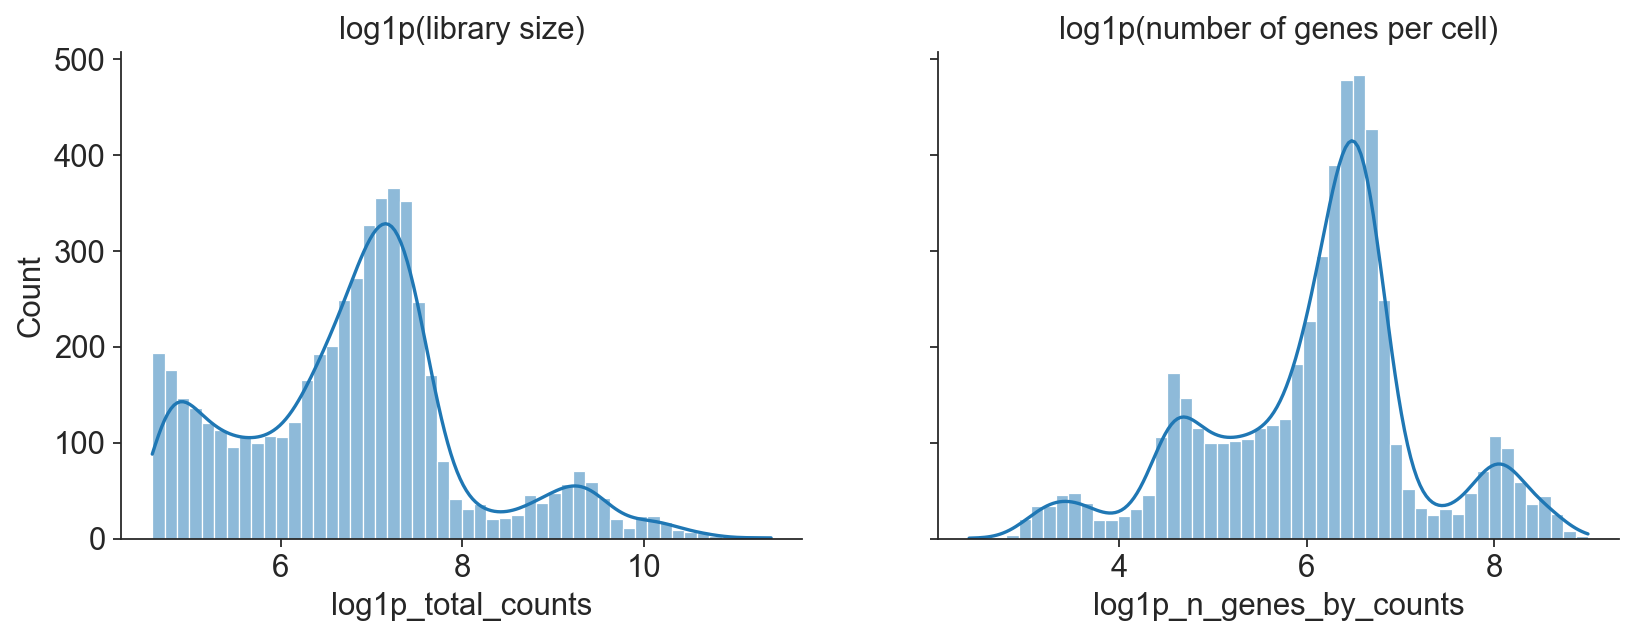

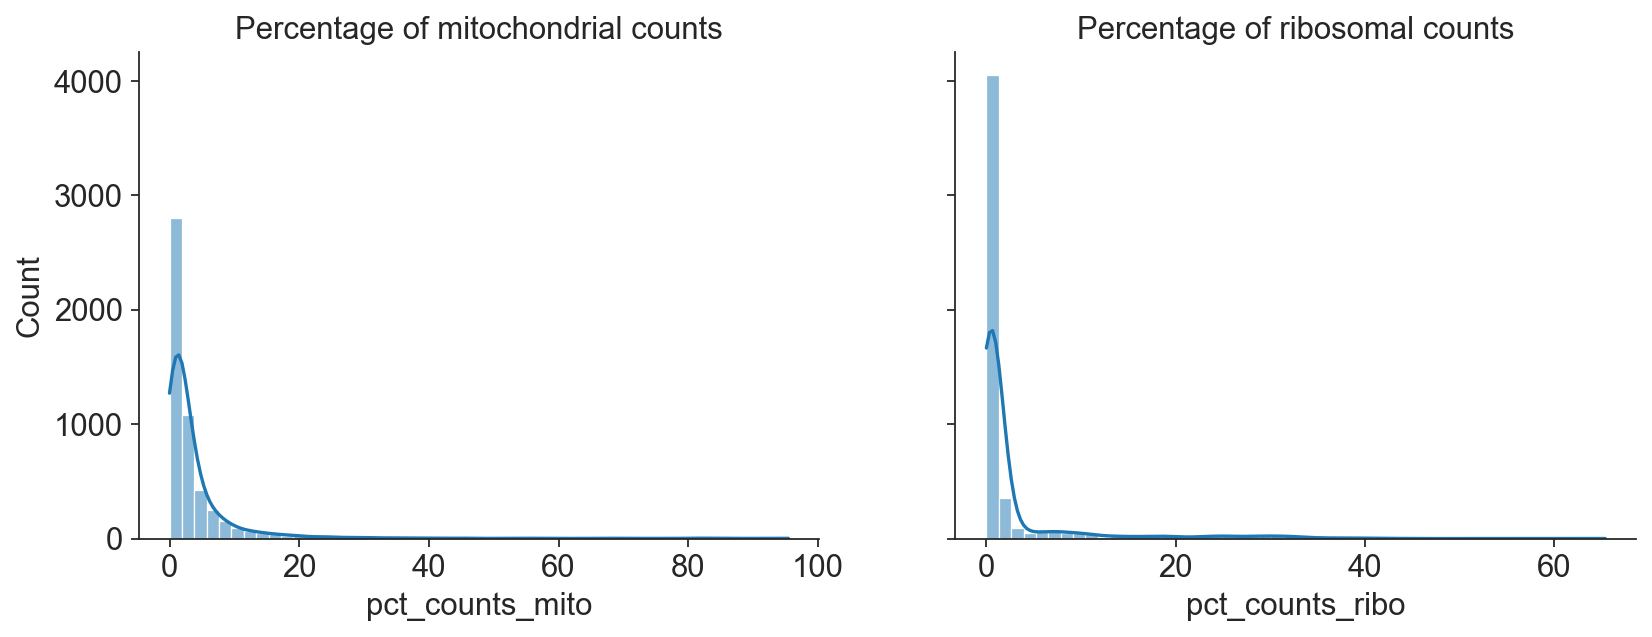

In [25]:
# Implement your solution here (single-QC plots)
fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)

sns.histplot(data=obs_data, x="log1p_total_counts", bins=50, kde=True, ax=ax[0])
ax[0].set_title("log1p(library size)")

sns.histplot(data=obs_data, x="log1p_n_genes_by_counts", bins=50, kde=True, ax=ax[1])
ax[1].set_title("log1p(number of genes per cell)")

fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)

sns.histplot(data=obs_data, x="pct_counts_mito", bins=50, kde=True, ax=ax[0])
ax[0].set_title("Percentage of mitochondrial counts")

sns.histplot(data=obs_data, x="pct_counts_ribo", bins=50, kde=True, ax=ax[1])
ax[1].set_title("Percentage of ribosomal counts")

plt.show()

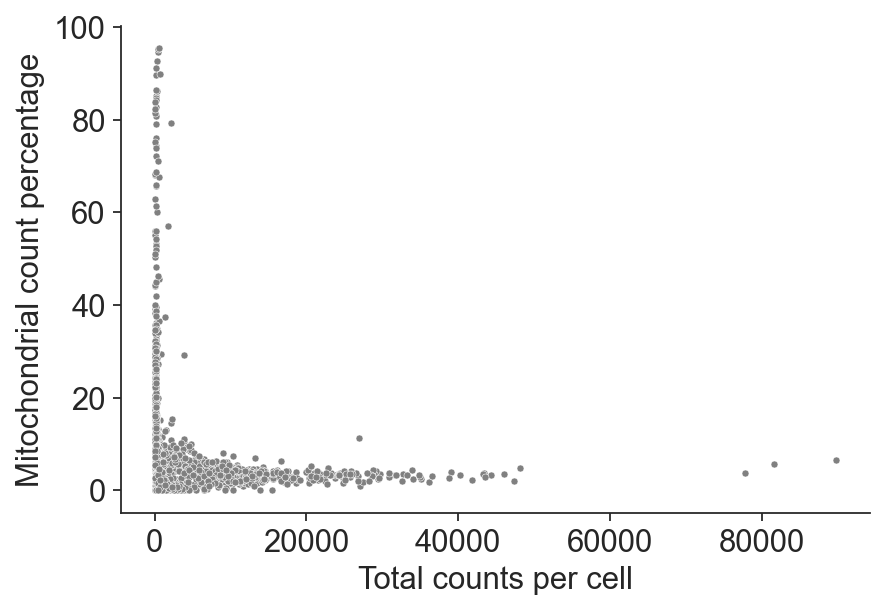

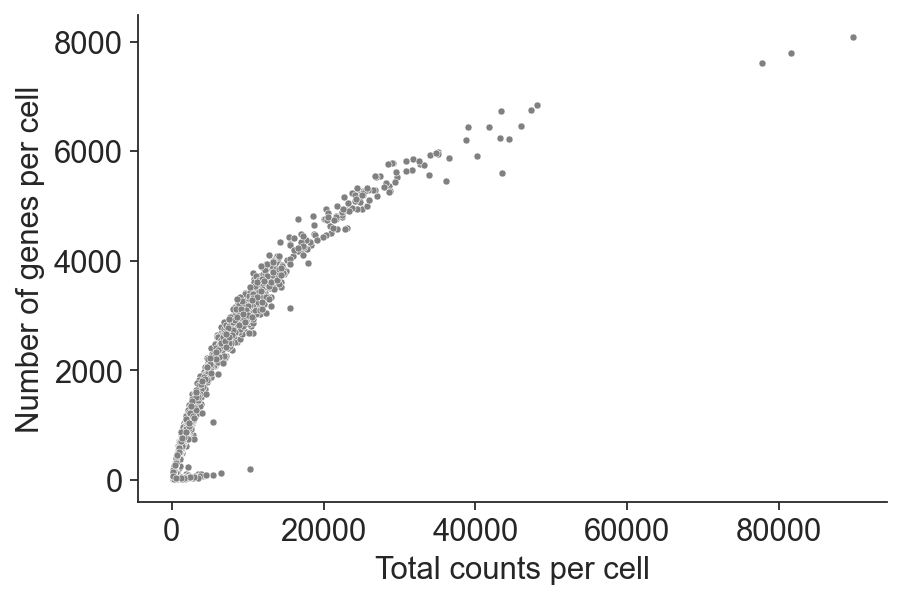

In [26]:
# Implement your solution here (QC metrics plotted against each other)
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=obs_data, x="total_counts", y="pct_counts_mito", s=10, color="grey", ax=ax)
ax.set(xlabel="Total counts per cell", ylabel="Mitochondrial count percentage")

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=obs_data, x="total_counts", y="n_genes_by_counts", s=10, color="grey", ax=ax)
ax.set(xlabel="Total counts per cell", ylabel="Number of genes per cell")
plt.show()

We can use the plots visualizing the relationship between mitochondrial count percentage and number of genes per cell versus the total counts per cell, respectively, to identify outlier cells. Specifically, we are looking for cell with
1. high percentage of mitochondrial genes and low total counts &rarr; likely dying cells
2. high number of genes expressed and large library size &rarr; potentially doublets

Remember that high/low are always compared to the rest of the data! Our thresholds for filtering also depends on the system we are studying as we naturally expect stressed cells in a disease of inflammatory context, for example.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.7</b>
  </div>
  Remove cells expressing more than 60,000 transcripts or where mitochondrial genes account for at least 20 percent of the transcripts.
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.5</b>
  </div>

  What is the dimension of our dataset after filtering?
  <blockquote>4990 cells and 15231 genes.</blockquote>
</div>

In [27]:
# Implement your solution here
row_mask = (obs_data["total_counts"] < 60000) & (obs_data["pct_counts_mito"] < 20)
row_mask = row_mask.values
counts = counts[row_mask, :].copy()
obs_data = obs_data.loc[row_mask, :].copy()

print(f"Number of cells: {counts.shape[0]}")
print(f"Number of genes: {counts.shape[1]}")

Number of cells: 4990
Number of genes: 15231


As a final step, we will perform the same analysis using Scanpy directly.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.8</b>
  </div>
  Repeat the quality control steps using Scanpy, i.e.,
  <ol type="a">
    <li>Remove cells expressing less than 100 transcripts.</li>
    <li>Remove genes expressed in less than 10 cells.</li>
    <li>Update the AnnData object with the cell- and gene-specific metrics defined above but no additional metrics.</li>
    <li>Remove cells expressing more than 60,000 transcripts and where mitochondrial genes account for at least 20 percent of the transcripts.</li>
  </ol>
</div>

In [28]:
# Implement your solution here (Scanpy-based workflow)
sc.pp.filter_cells(adata, min_counts=100)
sc.pp.filter_genes(adata, min_cells=10)

adata.var["mito"] = adata.var_names.str.upper().str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.upper().str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(adata, qc_vars=["mito", "ribo"], percent_top=(), log1p=True, inplace=True)

obs_mask = (adata.obs["total_counts"] < 60000) & (adata.obs["pct_counts_mito"] < 20)
adata = adata[obs_mask, :].copy()

adata

filtered out 2845 cells that have less than 100 counts
filtered out 21370 genes that are detected in less than 10 cells


AnnData object with n_obs × n_vars = 4990 × 15231
    obs: 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## 4. Data preprocessing

### Count normalization and transformation

Following filtering cells and genes and equivalent to standard data analysis pipeline, it is now time to normalize our observations. Normalization ensures that all cells are comparable relative to each other - an aspect not automatically guaranteed since the capture rate can vary dramatically across cells and, thus, heavily confounding the count values in scRNA-seq experiments. For example, does a value of '2' transcripts mean the same thing in a cell which had 10,000 transcripts, vs. one that is 1,000 transcripts? Probably not!

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.1</b>
  </div>
  <ol type="a">
    <li>Normalize the cell size to the median library size, and save the resulting array as <code>normalized_counts</code> in CSR format.</li>
    <li>Log1p-transform the normalized counts, and save the resulting array as <code>log1p_normalized_counts</code>.</li>
  </ol>
</div>

In [29]:
# Implement your solution here (normalization)
normalized_counts = counts / counts.sum(axis=1).reshape(-1, 1) * np.median(counts.sum(axis=1).A1)
normalized_counts = csr_matrix(normalized_counts)

In [30]:
# Implement your solution here (log1p-transformation)
log1p_normalized_counts = np.log1p(normalized_counts)

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.2</b>
  </div>
  <ol type="a">
    <li>Save the whole counts as a layer of <code>adata</code>, named <code>"counts"</code>.</li>
    <li>Normalize the data to the median library size.</li>
    <li>Log1p-transform the normalized data.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.1</b>
  </div>

  How can you keep track of whether or not your data is log1p-transformed in an AnnData-Scanpy-based workflow?
  <blockquote>Calling <code>scanpy.pp.log1p</code> adds an entry <i>log1p</i> to the <code>uns</code> slot.</blockquote>
</div>

In [31]:
# Implement your solution here
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


We will not z-score our data here, but it is an optional step to be aware of: in some cases, we want to scale each gene to zero mean and a standard deviation of 1. Such a transformation can also dramatically change the structure of your data.

The guiding principle here: there are many subjective choices in single-cell analysis, each of which can have major consequences on your embeddings, visualizations, differential expression, etc. It is a good idea to play around with your data with multiple iterations of processing before finalizing an analysis. Always think about your specific biological system and question, and how you might justify each choice you make.

### Feature selection

As a next step, we will identify genes we even want to consider or focuse on in our analysis (beyond those we filtered earlier for technical reasons). Intuitvely, we want to focus on genes varying across our observations as they contain non-redundant information; similarly, housekeeping genes are ubiquitously expressed and do not carry much information on biological heterogeneity. Highly-variable gene (HVG) selection accomplishes this goal by first defining a measure of how variable each gene is across cells in our dataset; thresholding defines HVGs; subsequent downstream analyses will operate on these HVGs to generate embeddings and visualizations of cells.

**Important:** unlike poorly-captured genes we filtered earlier, we do not actually want *remove* lowly-variable genes from your dataset entirely as some genes may be differential across conditions, cell types, etc. even when they are not statistically highly-variable. No method for detection of highly-variable genes is perfect, so the goal is to use HVGs for generating your embeddings/visualizations, but retaining all genes for future analysis.

At first thought, you might consider simply computing the empirical variance of each gene across cells as a measure of variability. However, the variance strongly correlates with mean expression, i.e., filtering based on variance is nearly equivalent to picking the most highly expressed genes overall! In reality, sometimes genes with a low mean expression are going to be the most important, such as those expressed highly in a rare population of cells.

To consider the scaling of the variance with the mean, the method developed by [Smillie et al. method](https://pubmed.ncbi.nlm.nih.gov/31348891/) attempts to find genes whose variance is higher than expected, given the mean expression of that gene. This is accomplished by first fitting a simple model where *dispersion* (the variance standardized by the mean) is a function of the mean, and the *residuals* (true dispersion - predicted dispersion) are a measure of variability. We will implement this method here, but Scanpy provides more robust and sophisticated HVG identification routines.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.3</b>
  </div>
  <ol type="a">
    <li>For each gene, compute the mean and standard deviation of its log1p-normalized expression.</li>
    <li>Compute the dispersion. To avoid dividing by zero, set zero mean values to 1 x 10-12</li>
    <li>Using statsmodels, fit a locally weighted scatterplot smoothing function to the log-dispersion and log-mean.</li>
    <li>Compute the residuals under the fitted model, and plot both the data, colored based on these residuals, and fitted curve.</li>
  </ol>
</div>

In [ ]:
# Implement your solution here (mean, standard deviation, and dispersion)
mean = log1p_normalized_counts.mean(axis=0).A1
mean[mean == 0] = 1e-12

var = log1p_normalized_counts.power(2).mean(axis=0).A1 - mean**2
dispersion = var / mean

In [33]:
# Implement your solution here (model fit and residual computation)
predicted_log_dispersion = lowess(np.log(dispersion), np.log(mean), return_sorted=False)
residuals = np.log(dispersion) - predicted_log_dispersion

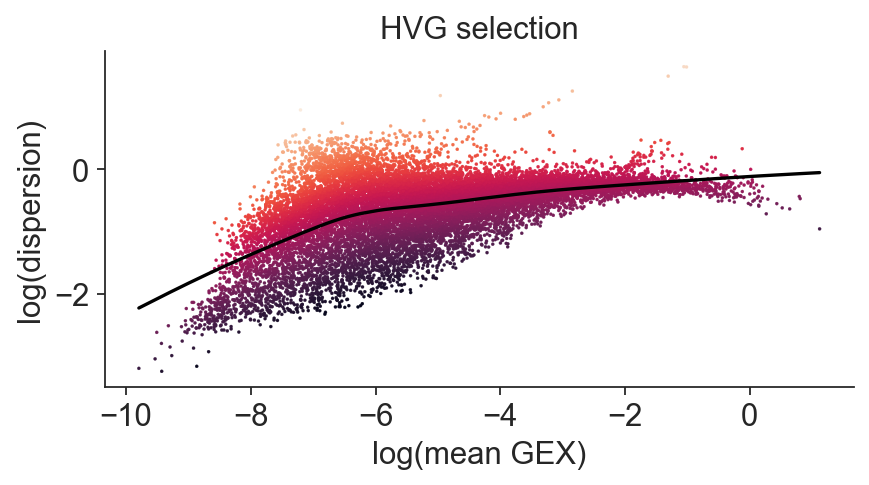

In [34]:
# Implement your solution here (plotting)
fig, ax = plt.subplots(figsize=(6, 6))

sns.scatterplot(x=np.log(mean), y=np.log(dispersion), s=2, c=residuals, edgecolor=None, ax=ax)
sns.lineplot(x=np.log(mean), y=predicted_log_dispersion, color="black", ax=ax)
ax.set(title="HVG selection", xlabel="log(mean GEX)", ylabel="log(dispersion)", aspect="equal")

plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.4</b>
  </div>
  Extract the 1000 most highly variable genes.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.2</b>
  </div>

  What are the 5 most highly variable genes?
  <blockquote>HBA1, HBG2, HBB, HBA2, LINC01534</blockquote>
</div>

In [35]:
# Implement your solution here (plotting)
hvgs = var_data.index[np.argsort(residuals)[-1000:]]
hvgs[-5:]

Index(['HBA1', 'HBG2', 'HBB', 'HBA2', 'LINC01534'], dtype='object')

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.5</b>
  </div>
  Identify and annotate the 2000 most highly variable genes. Only provide the minimal set of function arguments and use default parameters otherwise.
  </ol>
</div>

In [36]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

extracting highly variable genes
    finished (0:00:00)


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.6</b>
  </div>
  Subset the data to the 2000 HVGs identified with Scanpy.
</div>

In [37]:
# Implement your solution here
hvgs = adata.var_names[adata.var["highly_variable"]]
var_data["highly_variable"] = var_data.index.isin(hvgs)

var_mask = var_data["highly_variable"].values
var_data = var_data.loc[var_mask, :].copy()
counts = counts[:, var_mask].copy()
normalized_counts = normalized_counts[:, var_mask].copy()
log1p_normalized_counts = log1p_normalized_counts[:, var_mask].copy()

## Dimensionality reduction

With our data completely cleaned and a set of useful features selected, we will finally begin with embedding the cells in lower-dimensional space. Dimensionality reduction is often the first step to understanding your data. While we can glean very little from the way cells distribute in the 2000-dimensional space spanned along our highly-variable genes, the major axes of variation in this space can often be very interpretable. On top of that, dimensionality reduction can serve to de-noise our dataset. Most downstream analyses, such as visualization with UMAP or clustering cells, are often performed directly on reduced dimensions, rather than the full-dimensional per-gene data.

In this lab, we will use the most standard approach for dimensionality reduction: Principal Components Analysis (PCA), a linear decomposition method which places cells on axes upon which the variance of the data is maximized.

An extremely important step for downstream analysis is selecting which principal components to carry forward for visualization, graph building, and so forth. In PCA, the components are *ordered*, with the 'most important' components coming first. This ordering is based on a metric for the total amount of variance in the data explained by each component. If we were to compute all possible components (namely the total number of genes), we would explain all the variance, but generally we do not need to (or want to!) as later components tend to explain more of the *noise* and less of the *signal* in the data. We can choose a good number of PCs by plotting the variance ratio against the number of PCs, and selecting a threshold after which the variance added with additional PCs is negligible.


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.1</b>
  </div>
  <ol type="a">
    <li>Compute the first 50 principal components with sci-kit learn based on the log1p-normalized data.</li>
    <li>Plot the explained variance ratio agains the number of principal components.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 5.1</b>
  </div>

  What is a reasonable number of principal components to choose?
  <blockquote>30</blockquote>
</div>

In [38]:
# Implement your solution here (PC computation)
pca = PCA(n_components=50)
pcs = pca.fit_transform(log1p_normalized_counts)

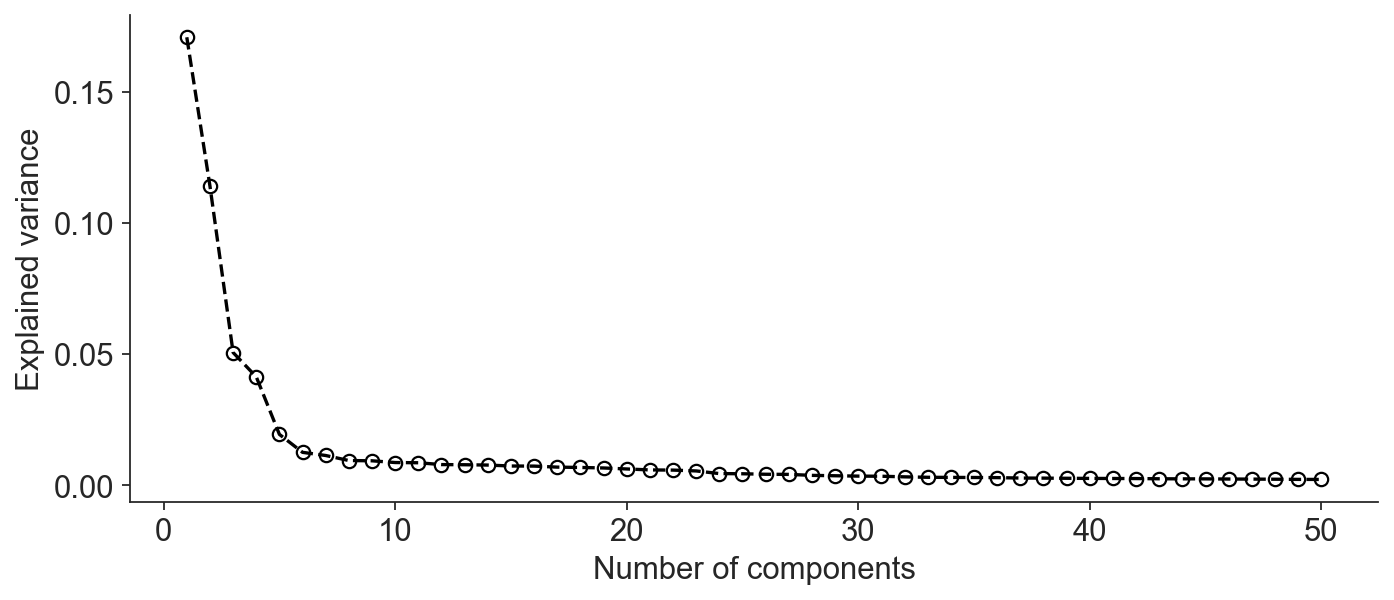

In [39]:
# Implement your solution here (plotting)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    np.arange(pca.n_components) + 1,
    pca.explained_variance_ratio_,
    marker="o",
    linestyle="--",
    color="black",
    markerfacecolor="none",
    markeredgecolor="black",
)
ax.set(xlabel="Number of components", ylabel="Explained variance")
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.2</b>
  </div>
  Select the 30 PCs associated with the highest explained variance ratio.
</div>

In [40]:
# Implement your solution here (plotting)
n_pcs = 30
pcs = pcs[:, :n_pcs]

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.3</b>
  </div>
  Compute the PCA embedding with 30 PCs.
</div>

In [41]:
# Implement your solution here (plotting)
sc.pp.pca(adata, n_comps=n_pcs)

computing PCA
    with n_comps=30
    finished (0:00:00)


### UMAP

Although PCA reduced our data representation from a 2000-dimensional space into a 30-dimensional space, visualizing data requires a 2D or 3D representation. An ideal compression will retain the global topology and relative distance between clusters - the objective of [Uniform Manifold Approximation and Projection](https://arxiv.org/abs/1802.03426) (UMAP; see [here](https://umap-learn.readthedocs.io/en/latest/how_umap_works.html) for an intuitive and illustrative explanation of the algorithm).

**Three important aspects to keep in mind:**

1. Never rely on 2D/3D representations for quantification! Always validate observations of findinings in higher-dimensional spaces such as the PCA representation or the original GEX space.
2. UMAP embeddings are rotation invariant &rarr; we can always rotate our embedding space to our preferred orientation
3. UMAP preserves the global topology and relative cluster distances &rarr; **ALWAYS** plot UMAP embeddings in square format with the aspect set to "auto" (default in Scanpy)

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.4</b>
  </div>
  <ol type="a">
    <li>Use the <i>umap</i> package to compute the 2D UMAP coordinates, based on a 30-nearest neighbor graph and an effective minimum distance between embedded points of 0.5.</li>
    <li>Add the coordinates as columns <code>"umap_1"</code> and <code>"umap_2"</code> to the appropriate DataFrame.</li>
    <li>Visualize the UMAP embedding.</li>
  </ol>
</div>

In [42]:
# Implement your solution here (plotting) (umap coordinates)
umap_model = UMAP(min_dist=0.5, n_neighbors=30)
obs_data[["umap_1", "umap_2"]] = umap_model.fit_transform(pcs)

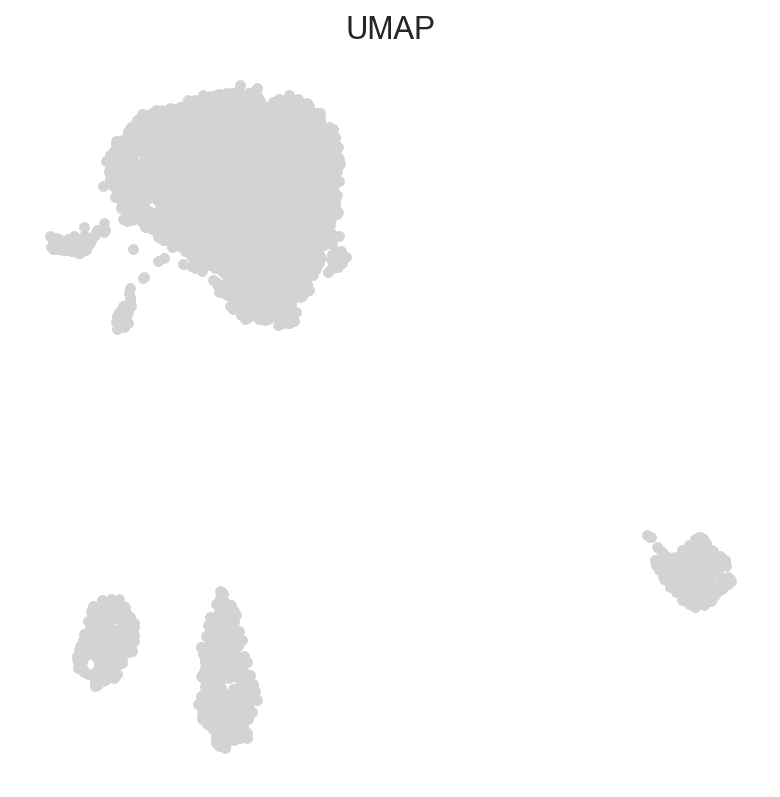

In [43]:
# Implement your solution here (plotting)
fig, ax = plt.subplots(figsize=(6, 6))

sns.scatterplot(data=obs_data, x="umap_1", y="umap_2", s=20, c="#D3D3D3", edgecolor=None, ax=ax)
ax.set_title("UMAP")
ax.axis("off")

plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 5.5</b>
  </div>
  <ol type="a">
    <li>Compute a k-nearest neighbor graph with k=30 (UMAP performs this step internally).</li>
    <li>Compute the umap embedding with an effective minimum distance between embedded points of 0.5.</li>
  </ol>
</div>

In [44]:
# Implement your solution here (neighbor graph and umap embedding)
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata, min_dist=0.5)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:04)


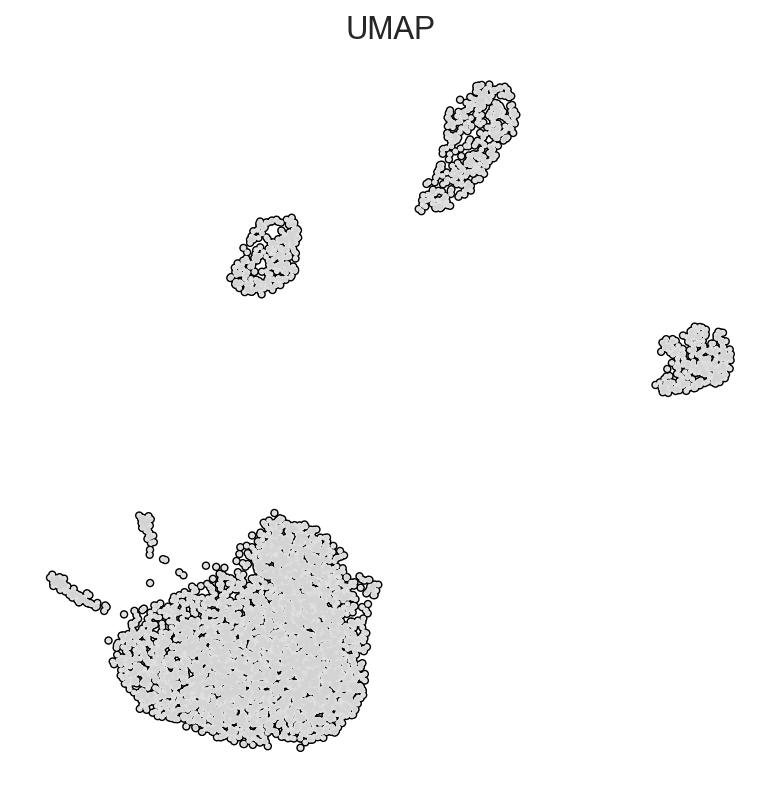

In [45]:
# Implement your solution here (plotting)
fig = sc.pl.embedding(adata, basis="umap", size=20, add_outline=2, return_fig=True)
fig.set_size_inches(6, 6)
ax = fig.get_axes()
ax[0].set(title="UMAP")
plt.show()

## Cell typing

Havin visualized our data, we observe different clusters which naturally leads us to the question: how can we systematically cluster cells based on their GEX profile, and what do these clusters encode biologically?

Here, we will use the Leiden algorithm to cluster our data: in a first step, the algorithm defines an initial, trivial partioning of a given kNN graph where each node is its own cluster. Following, the algorithm iteratively merges clusters to define partitions by taking into account the number of links between cells in a cluster compared to the overall expected number of links in the dataset.

<img src="https://www.sc-best-practices.org/_images/clustering.jpeg" alt="genescore" width="75%">

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.1</b>
  </div>
  <ol type="a">
    <li>Extract the weighted adjacency matrix from <code>adata</code>.</li>
    <li>Using the Python package *igraph* define the corresponding undirected and weighted graph object named <code>graph</code>.</li>
    <li>Compute the leiden clustering of <code>graph</code> based on the modularity objective and at resolution 1.</li>
    <li>Add the leiden cluster assignment as a colum <code>"leiden"</code> to the appropriate DataFrame.</li>
    <li>Plot the UMAP embedding colored by leiden cluster; use <code>vega_20_scanpy</code> for coloring.</li>
  </ol>
</div>

In [46]:
# Implement your solution here (igraph graph definition)
adjacency = adata.obsp["connectivities"].copy()
adjacency.eliminate_zeros()
sources, targets = adjacency.nonzero()

graph = Graph(directed=False)
graph.add_vertices(adjacency.shape[0])
graph.add_edges(list(zip(sources, targets, strict=True)))

graph.es["weight"] = adjacency.data

In [47]:
# Implement your solution here (leiden clustering)
from scanpy._utils.random import set_igraph_random_state  # isort: skip # noqa: E402

with set_igraph_random_state(0):
    partition = graph.community_leiden(weights="weight", resolution=1, objective_function="modularity")

groups = np.array(partition.membership, dtype="U")
obs_data["leiden"] = pd.Categorical(values=groups, categories=natsorted(map(str, np.unique(groups))))

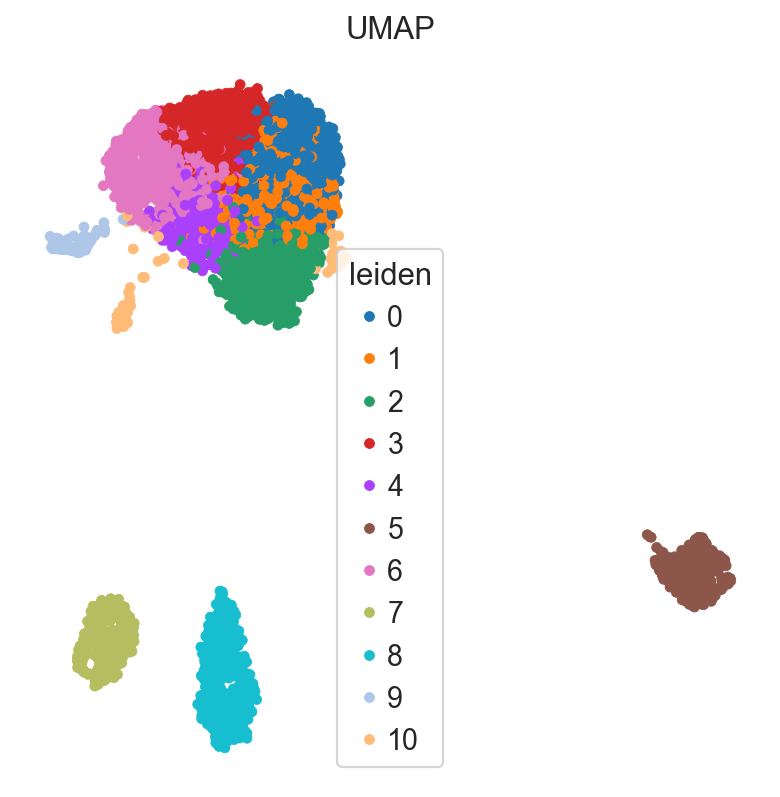

In [48]:
# Implement your solution here (plotting)
from scanpy.plotting.palettes import vega_20_scanpy  # isort: skip # noqa: E402

fig, ax = plt.subplots(figsize=(6, 6))

palette = dict(zip(obs_data["leiden"].cat.categories, vega_20_scanpy, strict=False))
sns.scatterplot(data=obs_data, x="umap_1", y="umap_2", s=20, hue="leiden", palette=palette, edgecolor=None, ax=ax)
ax.set_title("UMAP")
ax.axis("off")

plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.2</b>
  </div>
  Compute the Leiden clustering as before and visualize it in UMAP space.
</div>

running Leiden clustering
    finished (0:00:00)


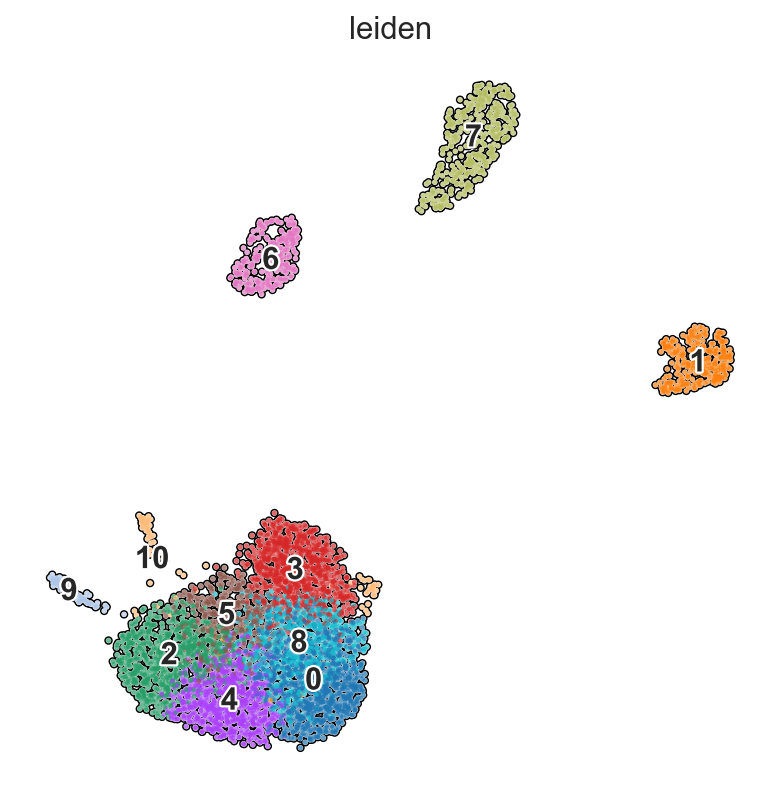

In [49]:
# Implement your solution here (leiden clustering)
sc.tl.leiden(adata, flavor="igraph")

fig = sc.pl.embedding(
    adata,
    basis="umap",
    color="leiden",
    size=20,
    add_outline=2,
    legend_loc="on data",
    legend_fontoutline=2,
    return_fig=True,
)
fig.set_size_inches(6, 6)
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.3</b>
  </div>
  To ensure reproducibility, update the leiden cluster annotation with <code>DATA_DIR / DATASET_ID / "results" / "leiden.parquet"</code>
</div>

In [50]:
# Implement your solution here (leiden clustering)
precomuted_leiden = pd.read_parquet(DATA_DIR / DATASET_ID / "results" / "leiden.parquet")
obs_data["leiden"] = precomuted_leiden.loc[obs_data.index, "leiden"]
adata.obs["leiden"] = precomuted_leiden.loc[adata.obs_names, "leiden"]

Finally, to associate the identified clusters with biology, we identify genes differentially expressed in each cluster compared to the rest of the data, ultimatly allowing us to assign cell type labels to these clusters, for example, by studying the expression of known markers in across the clusters.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(86, 104, 134); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.4</b>
  </div>
  <ol type="a">
    <li>Use a t-test to identify differentially expressed genes in leiden cluster 1 compared to all other cells. Assume that the variance between the two groups differs.</li>
    <li>Adjust the p-values using Benjamini-Hochberg.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 6.1</b>
  </div>
  <ol>
    <li>How many genes are significantly enriched in leiden cluster 1 at a false discover rate of 0.05?</li>
    <blockquote>26</blockquote>
    <li>Which are the three most differentially enriched genes?</li>
    <blockquote>HBA2, HBB, HBA1</blockquote>
  </ol>
</div>

In [51]:
obs_mask = obs_data["leiden"].isin(["1"]).values
group_1 = log1p_normalized_counts[obs_mask, :].toarray()
group_2 = log1p_normalized_counts[~obs_mask, :].toarray()

res = ttest_ind(group_1, group_2, equal_var=False)
res = pd.DataFrame({"names": var_data.index, "scores": res.statistic, "pvals": res.pvalue})
res["padj"] = false_discovery_control(res["pvals"].values)
res = res.sort_values("scores", ascending=False, ignore_index=True)
res.head()

,names,scores,pvals,padj
0,HBA2,194.986816,9.159387e-304,1.831877e-300
1,HBB,137.544079,4.006252e-260,4.006252e-257
2,HBA1,112.725297,1.505343e-234,1.003562e-231
3,UBA52,10.069689,1.359907e-20,9.962692e-20
4,RPS12,9.920125,3.548281e-20,2.507619e-19


In [52]:
n_degs = ((res["padj"] < 0.05) & (res["scores"] > 0)).sum()
print(f"Number of enriched DEGs: {n_degs}.")
print(f"Most DEGs: {', '.join(res['names'].values[:3])}")

Number of enriched DEGs: 26.
Most DEGs: HBA2, HBB, HBA1


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(134, 86, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.5</b>
  </div>
  Compute DEGs for all groups and print the results (gene names, scores, log fold changes, p values, and adjusted p values) for group 1 as a pandas DataFrame.
</div>

In [53]:
sc.tl.rank_genes_groups(adata, groupby="leiden", mask_var="highly_variable")
deg_res = sc.get.rank_genes_groups_df(adata, group="1")
deg_res.head()

ranking genes
    finished (0:00:00)


,names,scores,logfoldchanges,pvals,pvals_adj
0,HBA2,194.986832,13.587193,9.159111e-304,1.831822e-300
1,HBB,137.544067,13.163776,4.006290e-260,4.006290e-257
2,HBA1,112.725296,13.731324,1.505343e-234,1.003562e-231
3,UBA52,10.069689,2.332975,1.359908e-20,9.962694e-20
4,RPS12,9.920125,2.190808,3.548280e-20,2.507619e-19


`scanpy.pl.rank_genes_groups_dotplot` enables studying the expression of a set of given genes in the indentified Leiden cluster systematically: for each gene, the dot size indicates how many cells in a given group express a given gene, and the color of the dot encodes the group-specific mean expression. Here, we can see that cells in cluster 1 are likely Eryhtrocytes, and cells in cluster 7 T cells, for example.

    using 'X_pca' with n_pcs = 30
Storing dendrogram info using `.uns['dendrogram_leiden']`
categories: 0, 1, 2, etc.
var_group_labels: T, B, Neutrophil, etc.


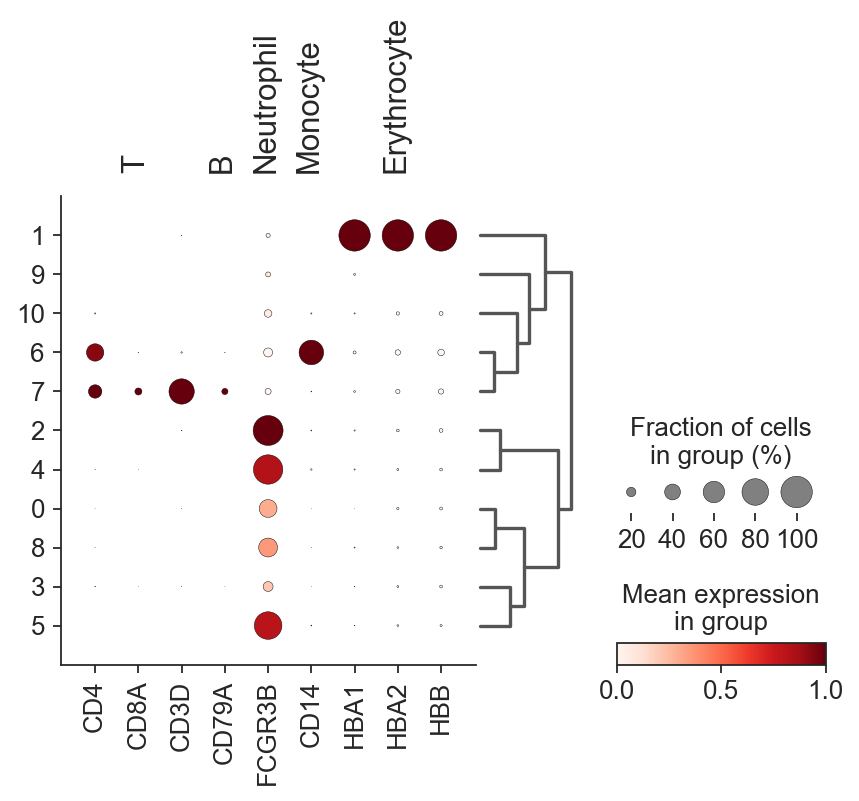

In [54]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    var_names={
        "T": ["CD4", "CD8A", "CD3D"],
        "B": ["CD79A"],
        "Neutrophil": ["FCGR3B"],
        "Monocyte": ["CD14"],
        "Erythrocyte": ["HBA1", "HBA2", "HBB"],
    },
    standard_scale="var",
)